# Reasoning Models — Introduction and Motivation

## Why Reasoning Models Are a New Topic

This topic is **very new**.

By *new*, we mean roughly **one year old**.

Almost everything discussed here comes from:
- **2024**
- **2025**

The advantage of learning this topic now is that we already have enough hindsight to understand:
- Which ideas actually mattered
- Which techniques turned out to be important
- Which approaches scaled well in practice

### Goals of This Lecture

By the end of this lecture, you should be able to answer two questions:

1. **What are reasoning models?**
2. **How are reasoning models trained?**

If you can answer these clearly, then the lecture has achieved its goal.

---

## What Is Reasoning?

Before defining *reasoning models*, we first need to define **reasoning** itself.

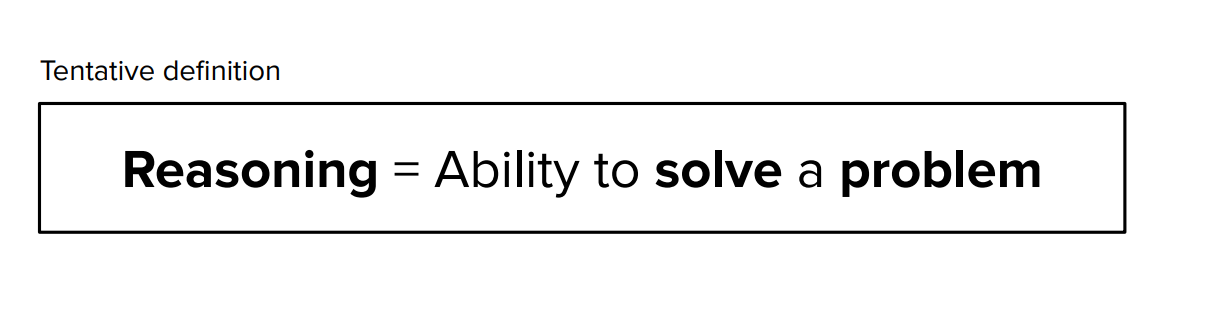


### No Universal Definition

There is **no commonly agreed-upon definition** of reasoning in the literature.

So here is a **practical working definition**:

> **Reasoning is the ability to solve a problem using a multi-step process.**

---

## What Kind of Problems Require Reasoning?

Typically, reasoning problems include:
- **Math problems**
- **Coding problems**
- Other tasks that require step-by-step thinking

The key idea is that:
- The solution is **not immediate**
- The problem must be **broken down into multiple steps**
- Each step builds toward the final answer

This is similar to how humans solve exam problems:
- Break the problem into parts
- Solve each part
- Combine results into a final answer

---

## Reasoning vs Non-Reasoning Questions

### Example: Non-Reasoning Question

> *What is the capital city of India?*

This is a **knowledge retrieval** question.

The answer is simply:
- **New Delhi**

No reasoning is required.


---

### Example: Reasoning Question

> *A bear was born in 2020. How old is the bear in 2025?*

This requires:
- Understanding years
- Computing a difference
- Applying a logical step

Even though this example is simple, it still qualifies as a **reasoning problem**.

More complex math or coding problems follow the same pattern, just with more steps.

---

## Context and External Information

Some reasoning problems require **context**.

For example:
- Knowing that the current year is **2025**
- Knowing today’s date

### How LLMs Handle Context

- LLMs typically receive a **preamble**
- The preamble often includes:
  - Current date
  - System instructions

So in many cases, contextual information (like the current year) is already available to the model.

### Missing Context

There are cases where:
- The model does **not** have required information
- External data must be fetched

This will be covered later (e.g., retrieval and tool use), and is **not foundational** to reasoning models themselves.

---

## Chain of Thought (CoT)

To understand reasoning models, we revisit an earlier concept:

### What Is Chain of Thought?

**Chain of Thought** means:
- Thinking in steps
- Explaining intermediate reasoning
- Not jumping directly to the final answer

Instead of:
> Answer

We want:
> Step 1 → Step 2 → Step 3 → Answer

---

### How Chain of Thought Works

Chain of Thought was originally introduced via **in-context learning**:

- The prompt includes examples
- Examples explicitly show reasoning steps
- The model learns to imitate this structure

This encourages the model to:
- Generate reasoning steps
- Then generate the final answer

---

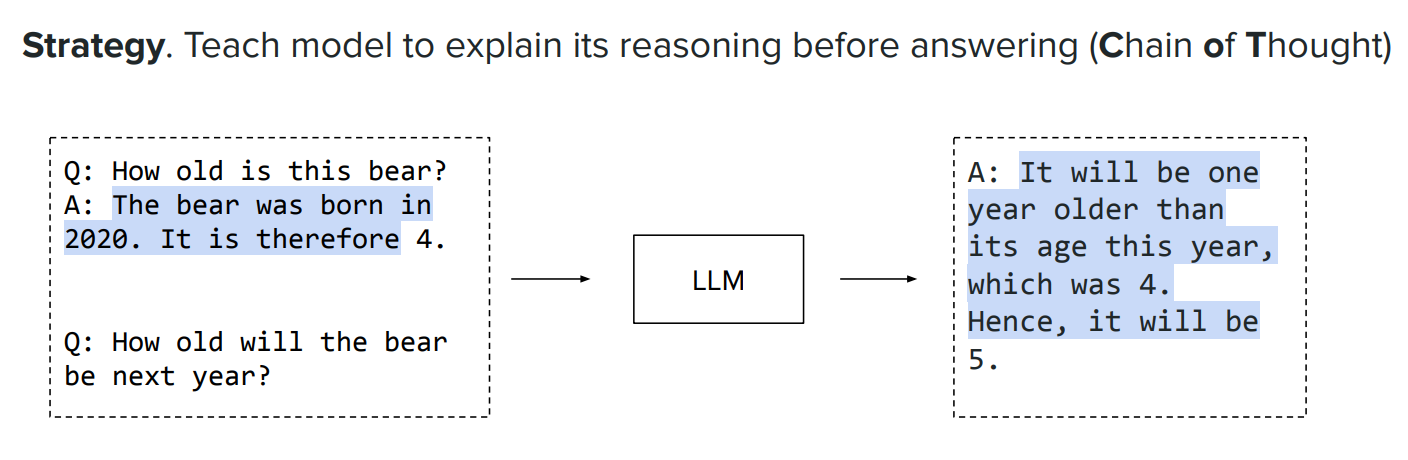

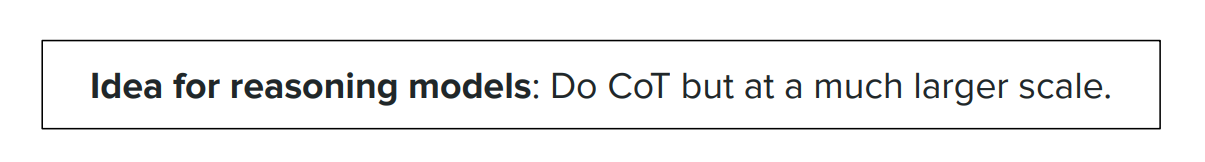

---
## Scaling Chain of Thought

What reasoning models do is **scale Chain of Thought** massively.

Instead of:
- A few in-context examples

We:
- Train models to **consistently reason**
- Across math, code, logic, and planning tasks

---

## Why Does Reasoning Help?

There are two key intuitions:

### 1. Decomposition Into Tractable Subproblems

LLMs are trained using **next-token prediction**.

For hard problems:
- The full problem likely never appeared in training
- The model struggles to directly generate the answer

By decomposing the problem:
- Each step resembles patterns seen during training
- The model can reuse learned structures

This is similar to human problem-solving:
- You map new problems to familiar ones
- You solve them piece by piece

---

### 2. More Tokens = More Compute

When a model reasons:
- It generates **more tokens**
- Each token requires a **full forward pass**

This effectively gives the model:
- More computation time
- More opportunities to refine its internal state

This idea is often described as:
> **Increasing the compute budget**

We will revisit compute budgets later.

---

## Definition: Reasoning Models

So far, traditional (vanilla) LLMs work like this:

**Question → Answer**

---
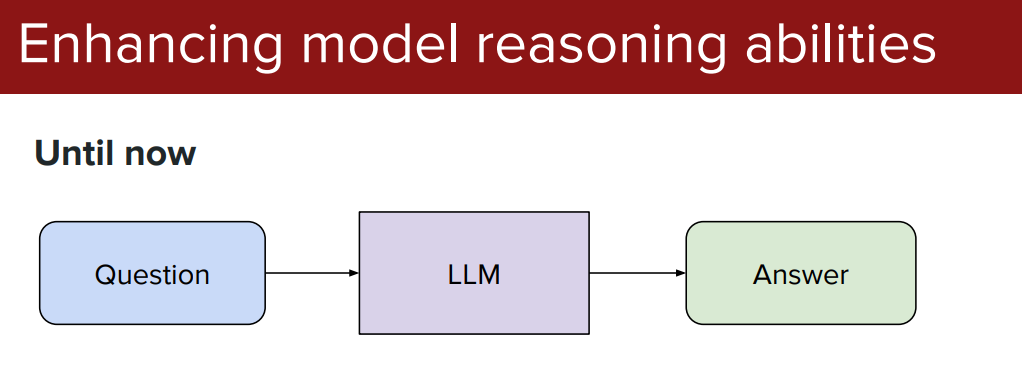



---
Reasoning models instead work like this:

**Question → Reasoning Chain → Answer**

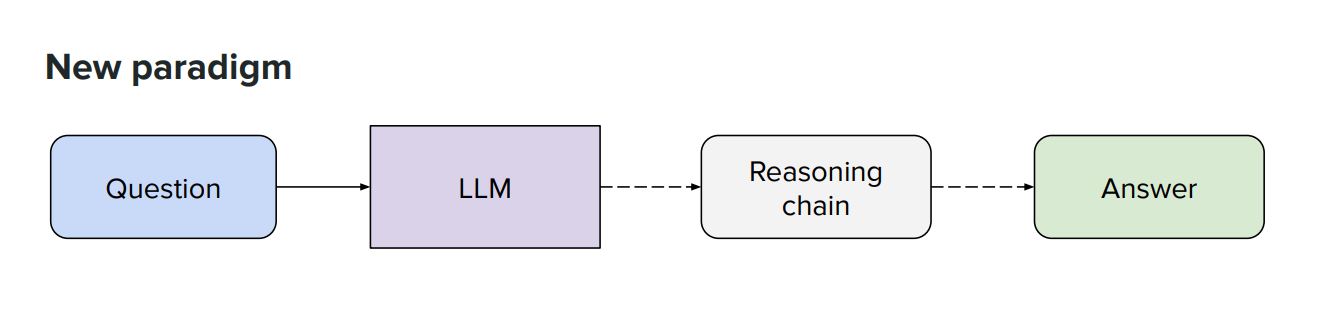
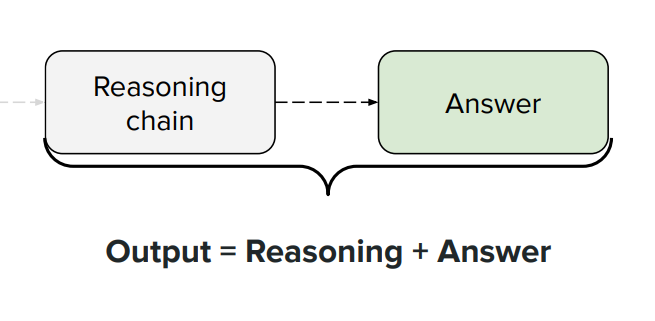
---
The **output** now includes:
- The reasoning
- The final answer

This is the defining characteristic of reasoning models.

---

## Timeline of Reasoning Models

Reasoning as a concept is old.

**Reasoning models**, however, are recent.

### Key Milestones

- **September 2024**  
  OpenAI releases **o1-preview**  
  → First major public reasoning model

- **December 2024**  
  Google releases **Gemini 2.0 Flash Thinking**

- **January 2025**  
  DeepSeek releases **DeepSeek R1**
  - Matches OpenAI reasoning performance
  - Fully described in a paper
  - Major moment for open research

- **2025 onward**
  - xAI
  - Anthropic (Claude)
  - Mistral
  - Other labs add reasoning capabilities

This timeline is not exhaustive, but shows how **recent and fast-moving** this field is.


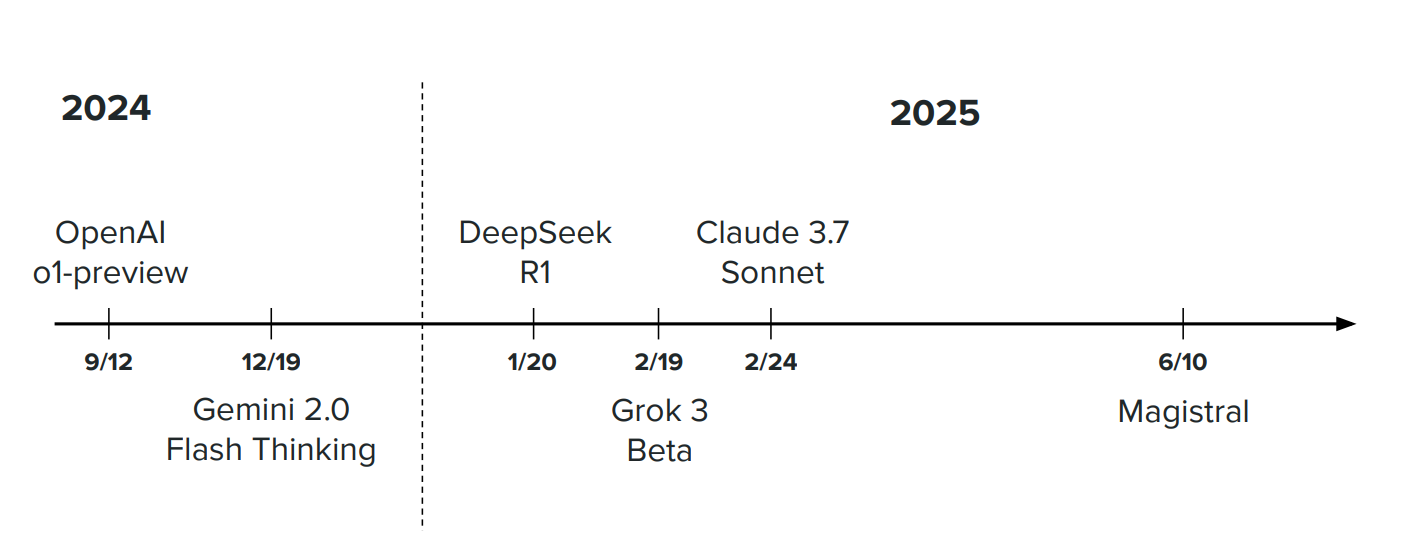
---

## Reasoning Models in User Interfaces

Most people interact with reasoning models through chat interfaces.

### How Can You Tell?

Look for words like:
- **“Thinking”**
- **“Reasoning”**
- **“Extended reasoning”**

These indicators suggest:
- The model is generating internal reasoning tokens

---

### Why You Don’t See Full Reasoning Chains

Typically, UIs do **not** show raw reasoning.

Instead, they show:
- A **summary of thoughts**
- Or just indicate that thinking occurred

Possible reasons:
1. Raw chains may not be human-readable
2. Users don’t want to read long chains
3. Revealing chains could allow imitation or distillation

---

## Cost and Token Accounting

Reasoning models:
- Generate more tokens
- Include reasoning tokens internally

Important note:
- **You are charged for reasoning tokens**
- Even if they are not shown

APIs usually charge for:
- All output tokens
- Including hidden reasoning tokens

This creates an incentive to:
- Maximize reasoning quality
- Minimize reasoning length

We will see techniques later that address this tradeoff.

---



# Reasoning Benchmarks — How Do We Measure Reasoning Ability?

So far, we discussed:
- What reasoning is (at least a tentative definition)
- The core idea behind reasoning models
- Why reasoning models generate intermediate steps

Now, we move to an important practical question:

> **How do we measure or quantify reasoning ability?**

To answer this, we look at **benchmarks**.

Benchmarks are standardized tasks that allow us to:
- Compare different models
- Track progress over time
- Quantify improvements in reasoning ability

---

## Coding Benchmarks for Reasoning

One major category of reasoning benchmarks focuses on **coding ability**.

### Goal of Coding Benchmarks

The goal is usually one of the following:
- Solve a coding problem
- Fix a bug
- Implement a function correctly

The typical evaluation setup is:

**Problem → Generated Code → Run Test Cases → Pass / Fail**
Problem → Reasoning Chain → Final Answer


If the generated solution:
- Passes **all test cases**, it is considered correct
- Fails even one test case, it is considered incorrect

This makes coding benchmarks particularly attractive because:
- Evaluation is **automatic**
- Correctness is **unambiguous**

---

## Common Coding Benchmarks

### HumanEval

- A well-known benchmark for code generation
- Consists of roughly **100+ human-written coding problems**
- Each problem includes:
  - A function signature
  - A docstring describing the task
  - Hidden test cases

The name *HumanEval* comes from the fact that:
- Problems were **written by humans**, not generated automatically

---

### CodeForces

- Derived from **competitive programming**
- Problems come from the CodeForces platform
- Typically more challenging than HumanEval
- Requires:
  - Algorithmic thinking
  - Optimization
  - Multi-step reasoning

Many reasoning models report performance on CodeForces-style problems.

---

### SWE-bench

- Focuses on **real-world software engineering**
- Problems are derived from:
  - GitHub issues
  - Bug reports
  - Feature requests

These tasks involve:
- Understanding existing codebases
- Fixing bugs
- Making minimal but correct changes

SWE-bench is valuable because:
- It reflects **practical, real-world reasoning**
- Not just toy coding problems

---

## Summary: Coding Benchmarks

Coding benchmarks test reasoning by requiring models to:
- Understand a problem
- Generate correct logic
- Pass formal verification via test cases

Because correctness can be checked automatically, coding benchmarks are:
- Reliable
- Widely used
- Easy to compare across models

---

## Math Benchmarks for Reasoning

Another major category of reasoning benchmarks focuses on **mathematics**.

### Goal of Math Benchmarks

The setup is typically:

**Problem → Reasoning Chain → Final Answer**


Here:
- The model is allowed (or encouraged) to generate reasoning
- Only the **final answer** is evaluated

---

## Verifying Math Answers

Unlike coding, math answers are not programs.

So how do we verify correctness?

### Ground Truth Comparison

- Each problem has a known **ground truth answer**
- The model’s output is parsed
- The parsed answer is compared against the ground truth

If they match:
- The solution is correct

If they do not:
- The solution is incorrect

---

## Parsing the Final Answer

To enable automatic evaluation, models are often instructed to:

- Output the final answer in a **specific format**
- For example:
  - Inside brackets
  - Inside a boxed expression
  - On a separate line

This is typically enforced via the **prompt**.

Example idea (conceptual):
`
Reasoning steps...
Final Answer: [42]
`

This makes it easy to:
- Extract the answer programmatically
- Compare it with the expected result

---

## Structure of Math Problems

A typical math benchmark problem looks like:

- A non-trivial question
- Requires multiple reasoning steps
- Produces a single numeric or symbolic answer

The model:
- Generates a reasoning chain
- Outputs the final answer in a parsable format

---

## Difficulty Level of Math Benchmarks

The math benchmarks used for reasoning models are **not trivial**.

Some commonly referenced benchmarks include:

### AIME

- American Invitational Mathematics Examination
- Used to qualify for the US Math Olympiad
- Problems require:
  - Deep reasoning
  - Algebraic manipulation
  - Multi-step logic

AIME problems are widely used to test:
- Advanced mathematical reasoning
- Structured thinking under constraints

---

### GSM8K

- Grade School Math 8K
- Focuses on:
  - Word problems
  - Arithmetic reasoning
  - Logical decomposition

Despite the name “grade school,” these problems are:
- Surprisingly challenging for LLMs
- Highly sensitive to reasoning quality

---

## Why Benchmarks Matter

At this point, a natural question arises:

> *We have all these benchmarks — but what metric do we actually use to decide if a model is good?*

This question leads directly into:
- Accuracy metrics
- Pass@k metrics
- Scaling behavior

These topics will be addressed next.

---



# pass@k — A Key Metric for Reasoning Benchmarks

There is one metric that you will see **very frequently** in reasoning papers, especially for **coding and math benchmarks**.

That metric is called **pass@k**.

---

## What is pass@k?

By definition, **pass@k** estimates:

> **The probability that at least one out of `k` generated attempts is correct.**

### Intuition

Suppose we have a coding problem.

- We ask the model to generate `k` solutions.
- Each solution is independently checked using test cases.
- If **at least one** of the `k` solutions passes all tests, we consider it a success.

So pass@k answers the question:

> *If I allow the model `k` tries, how likely is it that it gets the answer right at least once?*

---

## Why Does pass@k Make Sense?

This metric is useful in **real-world settings** where:

- You can afford more computation
- You can generate multiple attempts
- You can automatically verify correctness (e.g., code tests, math answers)

If generating more attempts increases the chance of success, then pass@k captures that benefit.

---

## Relation to Best-of-N

This idea is closely related to a technique we saw earlier:

### Best-of-N

- Generate `N` completions
- Score them (e.g., reward model or verifier)
- Return the best one

In **pass@k**, instead of:
- A reward model  
we use:
- A **deterministic verifier** (tests or exact answer matching)

So pass@k is essentially **Best-of-N with a verifier instead of a reward model**.

---

## Estimating pass@k Properly

A naive approach would be:
- Generate `k` samples
- Count how many are correct

But this estimate can be **very noisy**, especially for small `k`.

Instead, we do the following:

1. Generate **`n` total samples**
2. Out of these:
   - `c` are correct
   - `n - c` are incorrect
3. Use probability theory to estimate pass@k

---

## Probability Trick Used

To compute:

> Probability that **at least one** of `k` attempts is correct

We use the identity:

$$
P(\text{at least one success}) = 1 - P(\text{all failures})
$$

So:

$$
\text{pass@k} = 1 - P(\text{all } k \text{ attempts are incorrect})
$$

---

## Computing the Probability of All Failures

We sample **without replacement** from the `n` attempts.

### Step-by-step

- Probability first attempt is incorrect:

$$
\frac{n - c}{n}
$$

- Probability second attempt is incorrect (given first was incorrect):

$$
\frac{n - c - 1}{n - 1}
$$

- Continue this process `k` times:

$$
\frac{n - c}{n} \cdot \frac{n - c - 1}{n - 1} \cdot \dots \cdot \frac{n - c - k + 1}{n - k + 1}
$$

This gives the probability that **all `k` attempts are incorrect**.

---

## Expressing Using Factorials

We can rewrite the product using factorial notation:

### Numerator

$$
\frac{(n - c)!}{(n - c - k)!}
$$

### Denominator

$$
\frac{n!}{(n - k)!}
$$

Combining them:

$$
P(\text{all incorrect}) =
\frac{(n - c)!}{(n - c - k)!}
\cdot
\frac{(n - k)!}{n!}
$$

---

## Final pass@k Formula

Using combinations:

$$
\text{pass@k} = 1 - \frac{\binom{n - c}{k}}{\binom{n}{k}}
$$

This is the formula you will see **directly in papers**.

---

## Special Case: pass@1

If we set $k = 1$:

$$
\text{pass@1} = \frac{c}{n}
$$

This is simply:
- The probability that **a single generated answer is correct**
- Equivalent to standard accuracy

---

## Temperature and pass@k

Now we address an important question:

> **How does temperature affect pass@k?**

### Low Temperature ($T \approx 0$)

- Very deterministic outputs
- Low diversity
- Generating more samples does **not help**

So pass@k stays flat as `k` increases.

---

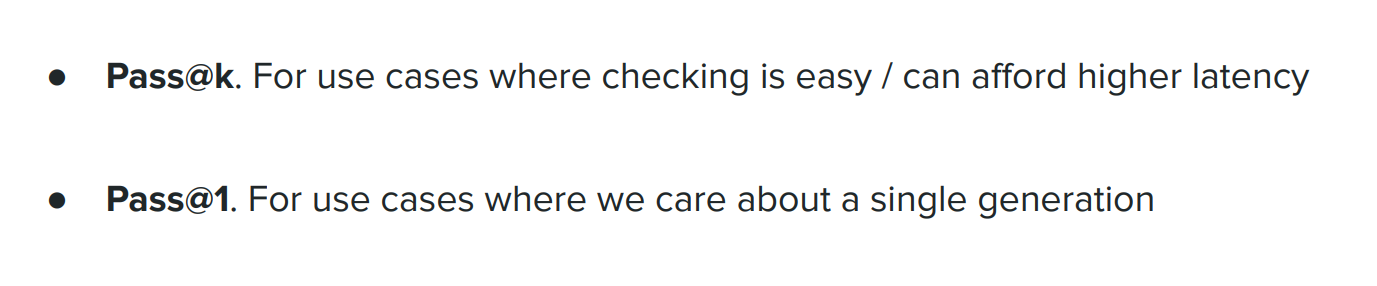


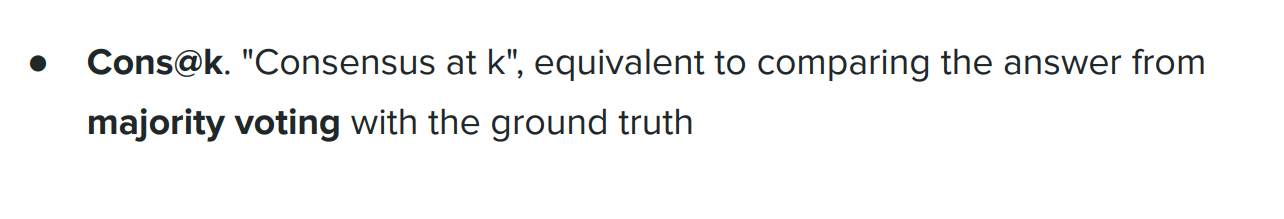


---
### Medium Temperature ($T \approx 0.4 - 0.8$)

- Balanced diversity
- Good solution quality
- pass@k increases significantly with `k`

This is typically the **best regime**.

---

### High Temperature ($T \ge 1.2$)

- High diversity
- But lower-quality generations
- Many unlikely tokens sampled

Result:
- pass@k may **decrease**
- More samples hurt performance

---

## Key Takeaway on Temperature

There is **no universal best temperature**.

That’s why:
- Papers always report the temperature used
- Benchmark results are temperature-dependent

---

## Other Related Metrics

Besides pass@k, you may also see:

### Consensus@k

- Selects the answer that appears **most frequently**
- Related to **self-consistency**

### Standard Metrics

- Accuracy
- Exact match
- Pass/fail rates

---

## Summary of pass@k

- pass@k measures **probability of success with multiple attempts**
- Very important for reasoning benchmarks
- Depends strongly on:
  - Number of samples
  - Temperature
  - Model diversity

This metric helps us understand:
> *How much reasoning improves when we give the model more chances.*

---



# Training Reasoning Models with Reinforcement Learning

So right now, we (hopefully) understand **what a reasoning model is**.  
Now we move to the **most interesting part of the lecture**:

> **How do we actually build a reasoning model?**

We know that:
- A reasoning model should **produce a reasoning chain**
- That reasoning chain should appear **before the final answer**

However, the main challenge is:

> **How do we make this happen at scale?**

This section focuses entirely on that question.

---

## Why Is This Hard?

The core idea is to **incentivize the model to produce a reasoning chain** before answering.

But there are several challenges.

---

## Why Not Just Use Supervised Fine-Tuning (SFT)?

At first glance, SFT sounds like a reasonable option:

> *“Let’s just train the model on reasoning chains.”*

But this approach has **major problems**.

---

### 1. Reasoning Chains Are Hard to Write

- Long reasoning chains are **very difficult to write**
- Writing them at scale is **extremely expensive**
- If we don’t already have reasoning chains, we would need to:
  - Write them manually
  - Or generate them somehow

Both options are very hard.

➡️ **This is a strong reason NOT to rely on SFT** if we start from scratch.

---

### 2. Human Reasoning ≠ Model Reasoning

Another important observation:

- The way **humans reason**
- Is not necessarily the way **models reason**

So even if we:
- Write high-quality human reasoning chains

They might **not be the best supervision signal** for how the model should reason internally.

➡️ This is another argument **against using human-written chains for SFT**.

---

### 3. Reasoning Tasks Have Natural, Verifiable Rewards

This is the key insight.

For reasoning tasks, we already have **built-in reward signals**:

#### Coding
- Does the code compile?
- Does it pass all test cases?

#### Math
- Is the final answer equal to the ground truth?

These rewards are:
- **Automatic**
- **Objective**
- **Easy to compute**

➡️ This makes **reinforcement learning a very natural choice**.

---

## If Not SFT, Then What?

Given:
- No reasoning chains
- Verifiable rewards
- Difficulty of human supervision

The natural solution is:

> **Use Reinforcement Learning (RL)**

And this fits perfectly with what we learned previously about:
- RL for LLMs
- Reward-based optimization

---

## How Do We Use RL for Reasoning?

Our goal is **twofold**:

1. Teach the model to **think**
2. Teach the model to **solve the problem correctly**

So we design a **reward function with two components**.

---

### Reward 1: Did the Model Produce a Reasoning Chain?

We can explicitly check this.

How?

- Instruct the model to wrap reasoning inside special tokens
  - For example: `<think> ... </think>`
- Check whether those tokens appear in the output

This is a **simple string-based check**.

✔️ No reward model required  
✔️ Fully automatic

---

### Reward 2: Is the Final Answer Correct?

Again, this is easy to verify.

- **Coding** → run tests
- **Math** → compare with ground truth

So the total reward is a **combination of**:
- Presence of a reasoning chain
- Correctness of the final answer

---

## Summary of the RL Setup

We run reinforcement learning where:

- The model generates:
  - A reasoning chain
  - A final answer
- The reward checks:
  1. Did the model think?
  2. Did it get the answer right?

This is **search-based RL with verifiable rewards**.

---

## Does This Actually Work?

Yes — and surprisingly well.

If we look at performance on benchmarks like **AIME** (a difficult math benchmark):

- As RL training progresses
- Model performance **increases significantly**

The graph shown in the lecture comes from **DeepSeek R1-Zero** training.

This shows that:

> **Just incentivizing “thinking + correctness” is enough to learn strong reasoning behavior**

No human-written chains needed.

---

## Controlling How Much the Model Thinks

Not all prompts require the same amount of reasoning.

Some questions:
- Are trivial
- Do not need long chains

Others:
- Are complex
- Require multi-step reasoning

This introduces a new challenge:

> **How do we control the amount of thinking?**

---

### Challenge 1: Overthinking Simple Questions

We don’t want the model to:
- Produce long reasoning chains for trivial prompts

One idea:
- Use a **lightweight classifier**
- Decide whether a prompt requires:
  - High reasoning
  - Low reasoning

This is still an **open research problem**.

---

### Challenge 2: Context Window Limits

LLMs have:
- A finite context window

If the model thinks too much:
- It may run out of context
- It may hurt final answer quality

So reasoning must be:
- Useful
- But bounded

---

## Budget Forcing

A technique introduced in the **S1 paper** is called:

> **Budget forcing**

The idea:
- Force the model to either:
  - Continue thinking
  - Or stop and answer

This can be done by:
- Injecting special tokens mid-generation
- Forcing behavior such as:
  - “Continue reasoning”
  - “Time is up, answer now”

---

## Natural Self-Correction in Reasoning Chains

Sometimes models naturally produce patterns like:

> “Wait, I think there is another approach…”

This causes the model to:
- Restart reasoning
- Explore a different path

This behavior can be:
- Encouraged
- Used as an implicit reasoning signal

---

## Beyond Token-Based Reasoning

Another active research direction:

> **Reasoning without explicit language tokens**

Instead of:
- Representing reasoning as text

We can:
- Represent reasoning as **hidden continuous states**

Benefits:
- More compact
- Potentially more expressive
- Not constrained by language

Several papers (2024–2025) explore this idea.

---

## Key Takeaway

If we start **without reasoning chains**, then:

- SFT is not ideal
- Human supervision is expensive
- Rewards are naturally verifiable

So the correct approach is:

> **Use Reinforcement Learning to incentivize thinking**

This is the foundation of modern reasoning models.

---



# GRPO: Group Relative Policy Optimization

We are now going to look at the **algorithm used to perform the RL step** for training reasoning models.

You may have heard this acronym a lot recently:

> **GRPO**

GRPO was released in **2024**, and it has quickly become the **go-to reinforcement learning algorithm** for:
- Reasoning models
- Reasoning-focused training pipelines

---

## What Is GRPO?

**GRPO** stands for:

> **Group Relative Policy Optimization**

It is a **reinforcement learning algorithm** that, at a high level, is conceptually similar to **PPO**, but with a **crucial difference**.

Just like PPO, GRPO aims to do **two things**:

1. **Maximize advantage**
2. **Prevent the policy from deviating too much** from:
   - The previous iteration’s model
   - The base (SFT) model

So in spirit, GRPO is very much aligned with PPO.

---

## Reminder: What Is Advantage?

Recall that **advantage** measures:

> How much better (or worse) a generated completion is compared to what we would expect on average.

- Positive advantage → reinforce this behavior
- Negative advantage → down-weight this behavior

This concept is central to both PPO and GRPO.

---

## How PPO Computes Advantage (Quick Recap)

In **PPO**, advantage estimation works as follows:

- You generate a **full completion** for a prompt
- You compute a **reward** for that completion
- PPO also trains a **value function** jointly with the policy
- The value function tries to predict the expected reward from partial generations
- Advantage is computed using **Generalized Advantage Estimation (GAE)**

Important points:
- Advantage estimation is **complex**
- Requires training an **extra value model**
- Adds **significant computational and engineering overhead**

This value function is one of PPO’s **big bottlenecks**.

---

## Key Idea of GRPO

GRPO makes a **deliberate design choice**:

> **No value function.**

Instead of estimating advantage via a learned value model, GRPO computes advantage **relatively**, using **groups of completions**.

This is where the word **“Group”** in GRPO comes from.

---

## How GRPO Computes Advantage

### Step 1: Generate Multiple Completions

For a **single prompt**:
- Generate **multiple completions**
- All completions share the **same prompt**

For example:
- Prompt: a math problem
- Generate 8 different solutions

---

### Step 2: Compute Rewards for Each Completion

For each completion:
- Compute a reward (e.g., correctness, reasoning present, etc.)

So now you have a **set of rewards**:

$$
\{ r_1, r_2, r_3, \dots, r_n \}
$$

---

### Step 3: Compute Group Average Reward

Compute the **average reward** across all completions for that prompt:

$$
\bar{r} = \frac{1}{n} \sum_{i=1}^{n} r_i
$$

---

### Step 4: Compute Relative Advantage

For each completion, the **advantage** is:

$$
A_i = r_i - \bar{r}
$$

This tells us:
- How much better or worse this completion is **relative to the group**

---

## Why Is This Powerful?

### No Value Function Needed

Unlike PPO:
- No value head
- No joint training of a value model
- No GAE

This significantly:
- Simplifies training
- Reduces instability
- Reduces memory usage

---

### Relative Context Matters

This relative advantage captures **difficulty-aware learning**.

Example intuition:

- Easy problem:
  - Most completions get high reward
  - Advantage values are small
- Hard problem:
  - Most completions fail
  - A correct solution stands out
  - Advantage is large and positive

This naturally:
- Upweights rare, high-quality solutions
- Especially on hard problems

---

## Why Relative Advantage Makes Sense for LLMs

Traditional RL algorithms (like PPO):
- Were designed **before LLMs**
- Targeted environments very different from language generation

GRPO is designed **with LLMs in mind**:

- Language tasks naturally allow multiple sampled completions
- Relative comparison between completions is intuitive
- No need to predict long-term value like in robotics or games

So instead of asking:
> “What reward should I expect in the future?”

GRPO asks:
> “How good is this completion compared to other completions for the same prompt?”

---

## Intuition with an Example

Consider two math problems:

### Easy Problem
- Most completions are correct
- High reward is expected
- Advantage remains small

### Hard Problem
- Most completions fail
- One correct solution appears
- That solution has **very high relative advantage**

GRPO naturally emphasizes:
- Rare, high-quality reasoning
- Without explicitly modeling difficulty

---

## Summary: Why GRPO Works Well

GRPO:
- Removes the need for a value function
- Uses **group-relative rewards**
- Is simpler than PPO
- Is more stable for LLM reasoning tasks
- Aligns well with sampling-based language generation

This is why:
> **GRPO has become the default RL algorithm for reasoning models**

---



# GRPO vs PPO — Walkthrough and Comparison

Now we will go through **the exact same process again**, but this time we will **walk through it step by step** to clearly see **how GRPO works in practice**, and how it differs from PPO.

---

## GRPO: End-to-End Walkthrough

### Step 1: Query → Policy Model

- We start with a **query (prompt)**.
- This query is passed through the **policy model**, which is the **LLM we are training**.

---

### Step 2: Generate Multiple Completions

- Unlike PPO, **we do not generate just one completion**.
- We generate **g completions** for the **same query**.

So we now have:

$$
\{ (x, y_1), (x, y_2), \dots, (x, y_g) \}
$$

Each pair shares the same query `x`.

---

### Step 3: Compute Rewards

- Each query–completion pair is passed through the **reward mechanism**.
- This gives us **g rewards**:

$$
\{ r_1, r_2, \dots, r_g \}
$$

> In reasoning tasks, this reward is **verifiable** (correct answer, passing tests, etc.),  
> so **no learned reward model is required**.

---

### Step 4: Compute Group-Based Advantage

Previously, we said:

> Advantage = reward − average reward

But in **GRPO**, the definition is slightly more refined.

The advantage is computed as:

$$
A_i = \frac{r_i - \mu}{\sigma}
$$

Where:
- $$\mu$$ = mean of rewards in the group
- $$\sigma$$ = standard deviation of rewards in the group

This **normalizes** the advantage.

> Note: This normalization is a design choice, and it may not always be optimal — we’ll discuss that later.

---

### Step 5: Policy Update with KL Constraint

- These advantages are then used to **update the policy model**.
- At the same time, we ensure the policy **does not deviate too much** from the **reference model**.

This is enforced using a **KL divergence penalty**:

$$
\mathrm{KL}(\pi_\theta \,\|\, \pi_{\text{ref}})
$$

---

### Summary of GRPO Flow

- One query
- Multiple completions
- Multiple rewards
- **Group-relative advantage**
- No value function
- KL constraint to reference model

---

## PPO: End-to-End Walkthrough (For Comparison)

### Step 1: Query → Policy Model

- Start with a **query**
- Pass it through the **policy model**

---

### Step 2: Generate a Single Completion

- PPO generates **only one completion** per query.

$$
(x, y)
$$

---

### Step 3: Reward Computation

- The `(query, completion)` pair is passed through a **reward model**
- This produces **one reward for the entire completion**

---

### Step 4: Token-Level Rewards (Implementation Detail)

In practice:
- Rewards are often **distributed across tokens**
- Only the **last token** gets the main reward
- Every token gets a **KL penalty** comparing:
  
$$
\pi_\theta \text{ vs } \pi_{\text{ref}}
$$

This is an implementation detail, but good to be aware of.

---

### Step 5: Value Function

- PPO trains a **value function** jointly with the policy
- The value function:
  - Operates at **token level**
  - Predicts expected future reward if generation continues

---

### Step 6: Advantage via GAE

- Advantage is computed using:
  - Reward
  - Value function
  - **Generalized Advantage Estimation (GAE)**

This involves a **complex formula** we did not derive.

---

## Models Used in Each Method

### Shared (Frozen) Models

Both GRPO and PPO use:
- **Reference model** (for KL divergence)

In reasoning tasks:
- **No reward model is trained**
- Rewards are **verifiable**

---

### Trainable Models

| Method | Trainable Models |
|------|------------------|
| GRPO | Policy model only |
| PPO  | Policy model + Value model |

> This is the **key architectural difference**.

---

## Loss Function Comparison (High-Level)

We now compare the **GRPO loss** and **PPO loss**.

### Similarities

1. Both use the **probability ratio**:

$$
\frac{\pi_\theta(a|s)}{\pi_{\theta_{\text{old}}}(a|s)}
$$

2. Both use **clipping** to prevent large updates
3. Both aim for **stable policy updates**

---

### Differences

#### 1. KL Divergence Placement

- **GRPO**: KL divergence is **explicitly part of the loss**
- **PPO**: KL divergence is typically **folded into the reward / advantage**

---

#### 2. Advantage Computation

- **GRPO**:
  - Uses **group-relative rewards**
  - No value function

- **PPO**:
  - Uses reward + value function
  - Requires GAE
  - More complex and expensive

---

## Key Takeaways

- **PPO**
  - Used heavily for preference tuning
  - Requires value function
  - Complex and expensive

- **GRPO**
  - Designed for reasoning tasks
  - No value function
  - Advantage computed via **group comparison**
  - Much simpler and more scalable

---

## Mental Model to Remember

- **PPO advantage**:
  - Reward − Value estimate

- **GRPO advantage**:
  - Reward − Average reward of group

If this distinction is clear, then you’ve understood **the hardest part of the course**.

---



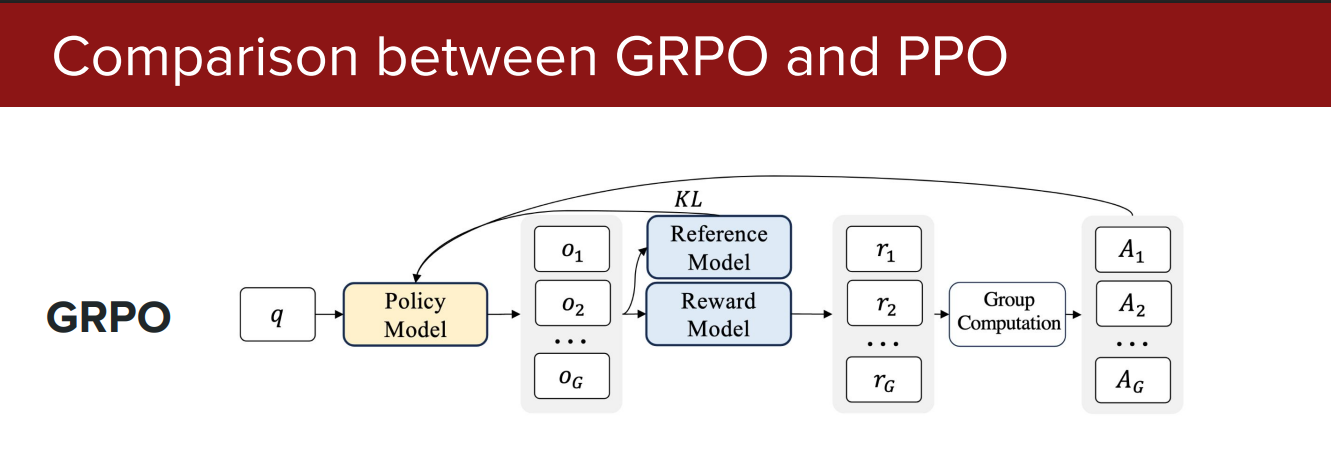
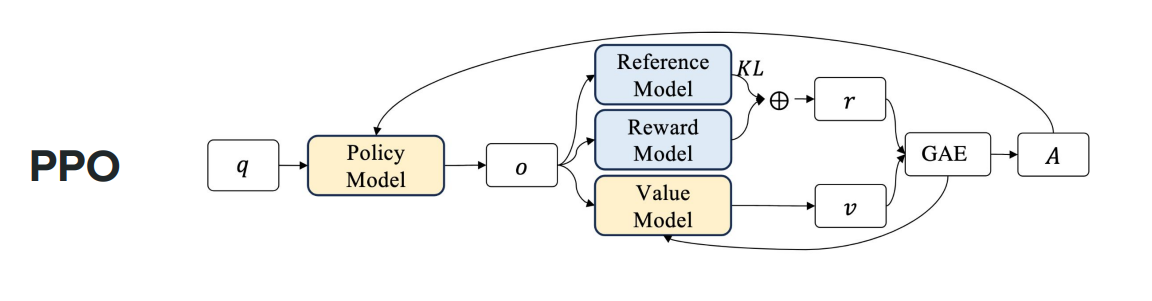

## Loss Function

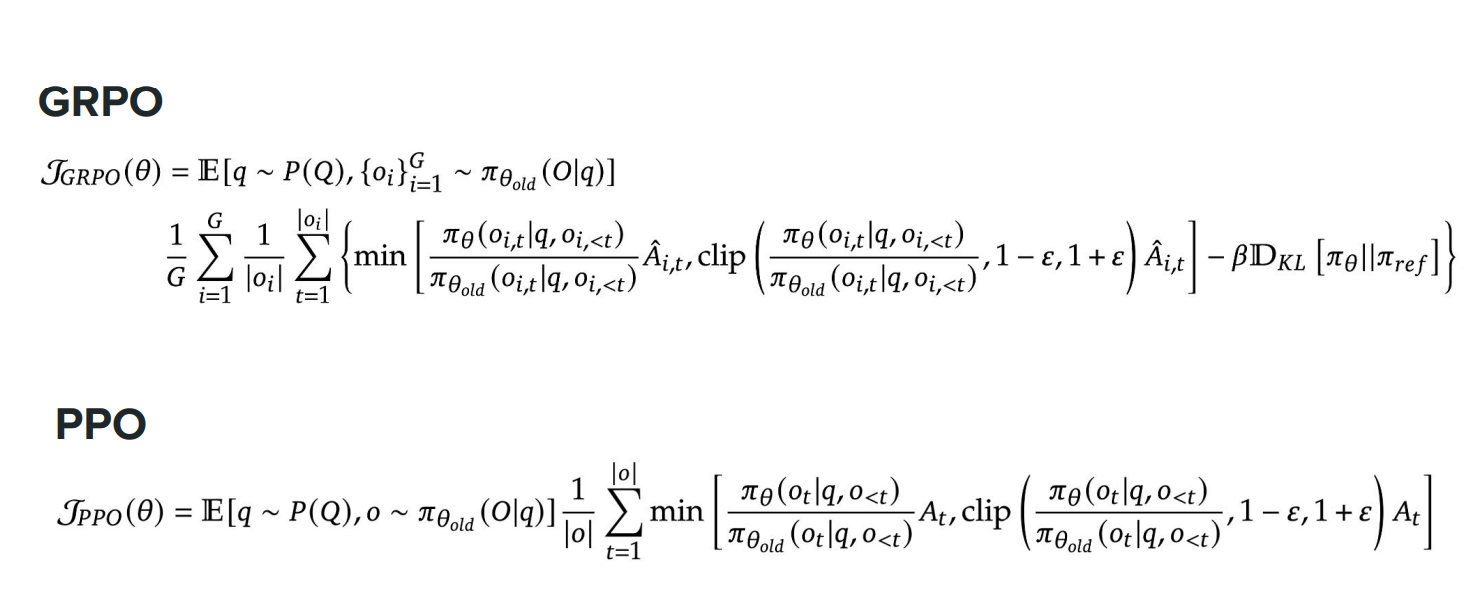



# Extensions of GRPO: Controlling Reasoning Length and Efficiency

This section discusses **recent extensions of GRPO (early 2025)** that address a critical issue in reasoning models:  
**uncontrolled growth of reasoning length**.

This topic is important both:
- **For users** (reasoning tokens are billed)
- **For providers** (longer outputs = higher compute cost)

---

## Observation: Reasoning Length Grows During RL

Empirically, during RL training:

- As **RL steps increase**,  
  → **average output length increases**
- This increase is driven mainly by **longer reasoning chains**

Initially:
- Longer reasoning correlates with **better performance**

Later:
- Performance **plateaus**
- Output length **keeps increasing**

This indicates a **misaligned incentive** in the GRPO objective.


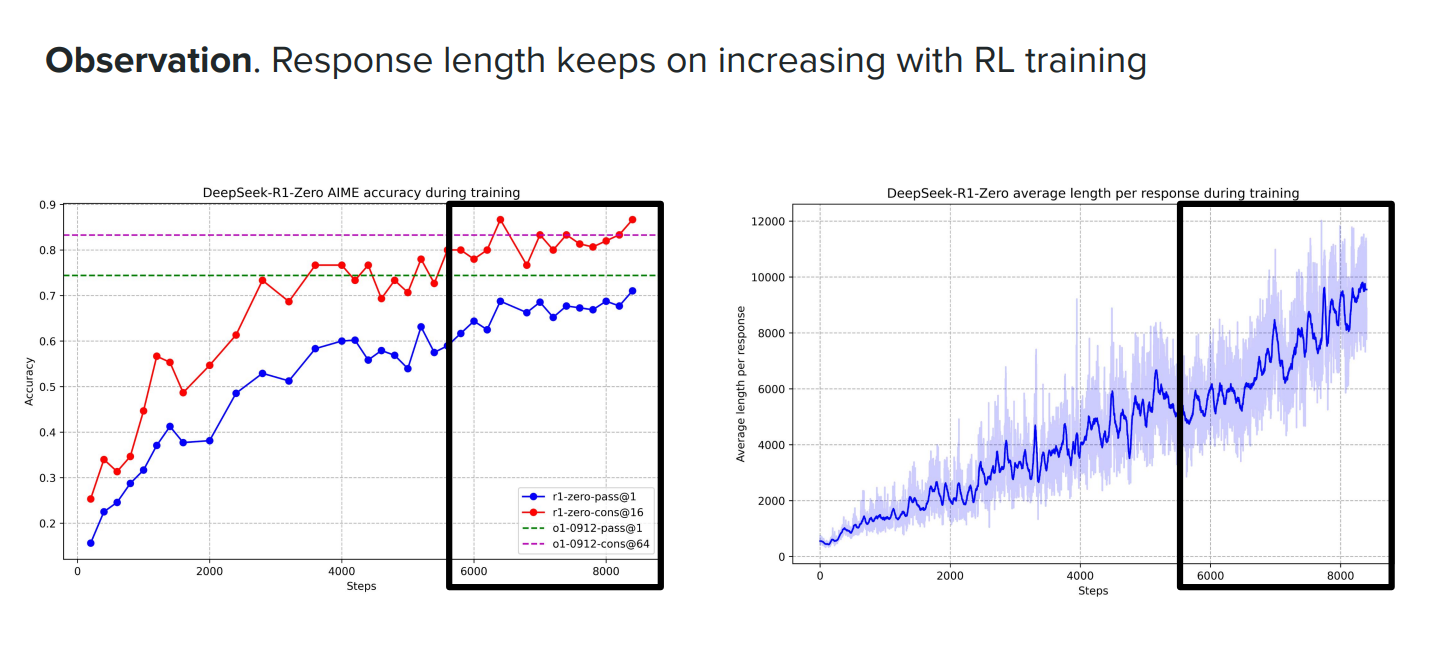
---

## Why Does Output Length Keep Growing?

To understand this, we must examine the **GRPO objective function**.

---

## GRPO Objective (High-Level)

The GRPO objective aims to maximize:

- Relative improvement over old policy
- While staying close to the reference model

Formally, the GRPO objective can be written as:

$$
J_{\text{GRPO}} =
\mathbb{E}\left[
\sum_{i=1}^{G}
\frac{1}{|o_i|}
\sum_{t=1}^{|o_i|}
\min\left(
r_{i,t}(\theta) A_i,
\text{clip}(r_{i,t}(\theta), 1-\epsilon, 1+\epsilon) A_i
\right)
-
\beta \, \mathrm{KL}(\pi_\theta \| \pi_{\text{ref}})
\right]
$$


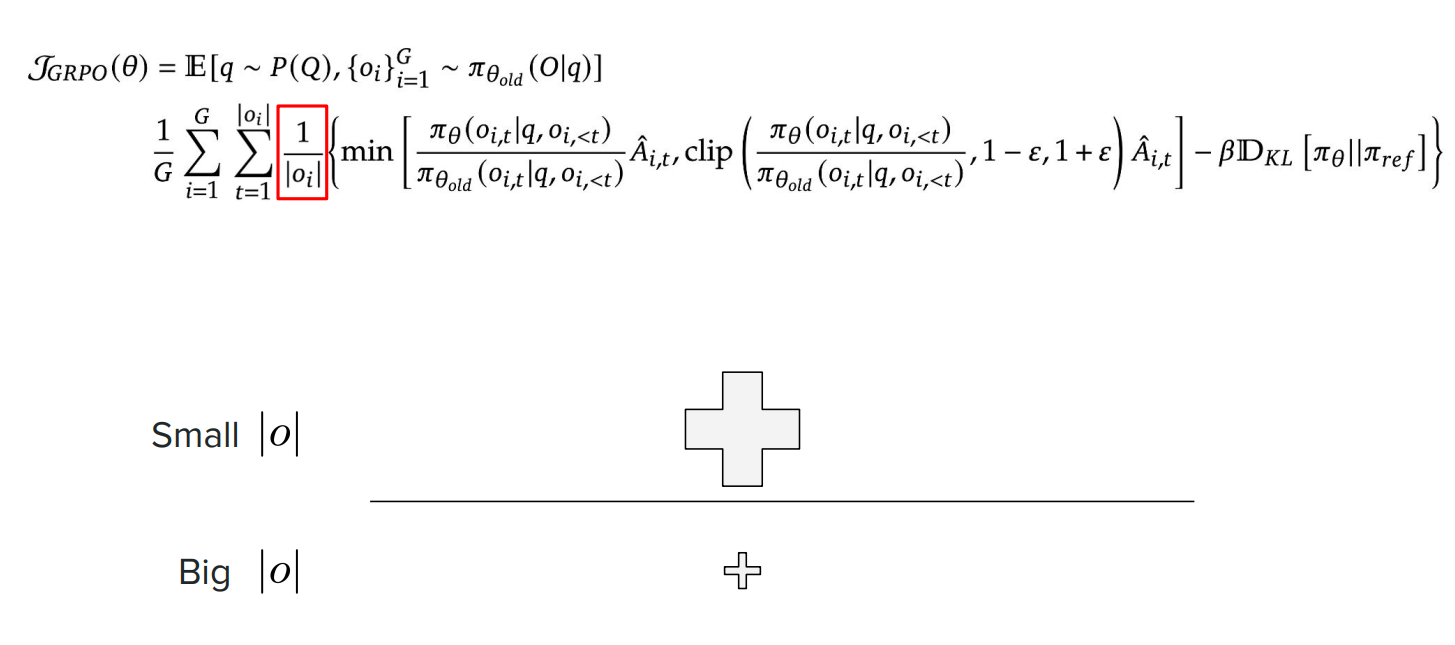


Where:
- $G$ = number of completions in the group
- $|o_i|$ = length of output $i$
- $t$ = token index
- $A_i$ = group-relative advantage
- $r_{i,t}(\theta)$ = policy ratio
- $\beta$ = KL penalty coefficient

---

## Key Structural Detail: The Length Normalization Term

Focus on this factor:

$$
\frac{1}{|o_i|}
$$

This term:
- Depends **only on output length**
- Is applied to **every token in that output**

---

## Token-Level Interpretation

Consider two outputs:

- **Short output** → small $|o_i|$ → large $\frac{1}{|o_i|}$
- **Long output** → large $|o_i|$ → small $\frac{1}{|o_i|}$

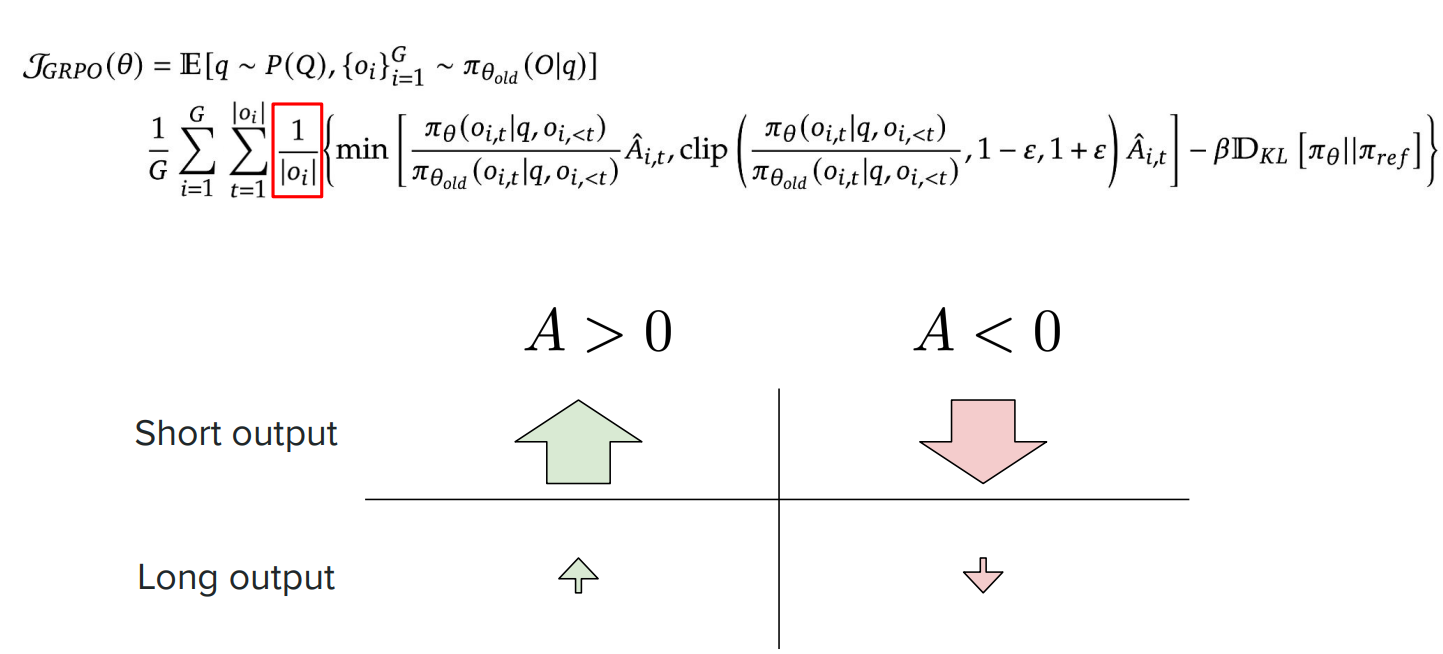

Therefore:

- Tokens in **short outputs** have **larger influence**
- Tokens in **long outputs** have **smaller influence**

---

## Interaction with Advantage

### Case 1: Positive Advantage

If $A_i > 0$:
- Tokens should be **upweighted**

But:
- Short outputs get **stronger positive updates**
- Long outputs get **weaker positive updates**

---

### Case 2: Negative Advantage (Critical Case)

If $A_i < 0$:
- Tokens should be **downweighted**

But:
- Short bad outputs get **stronger punishment**
- Long bad outputs get **weaker punishment**

---

## Core Problem

This creates a **bad incentive**:

> A **short incorrect output** is penalized **more**  
> than a **long incorrect output**

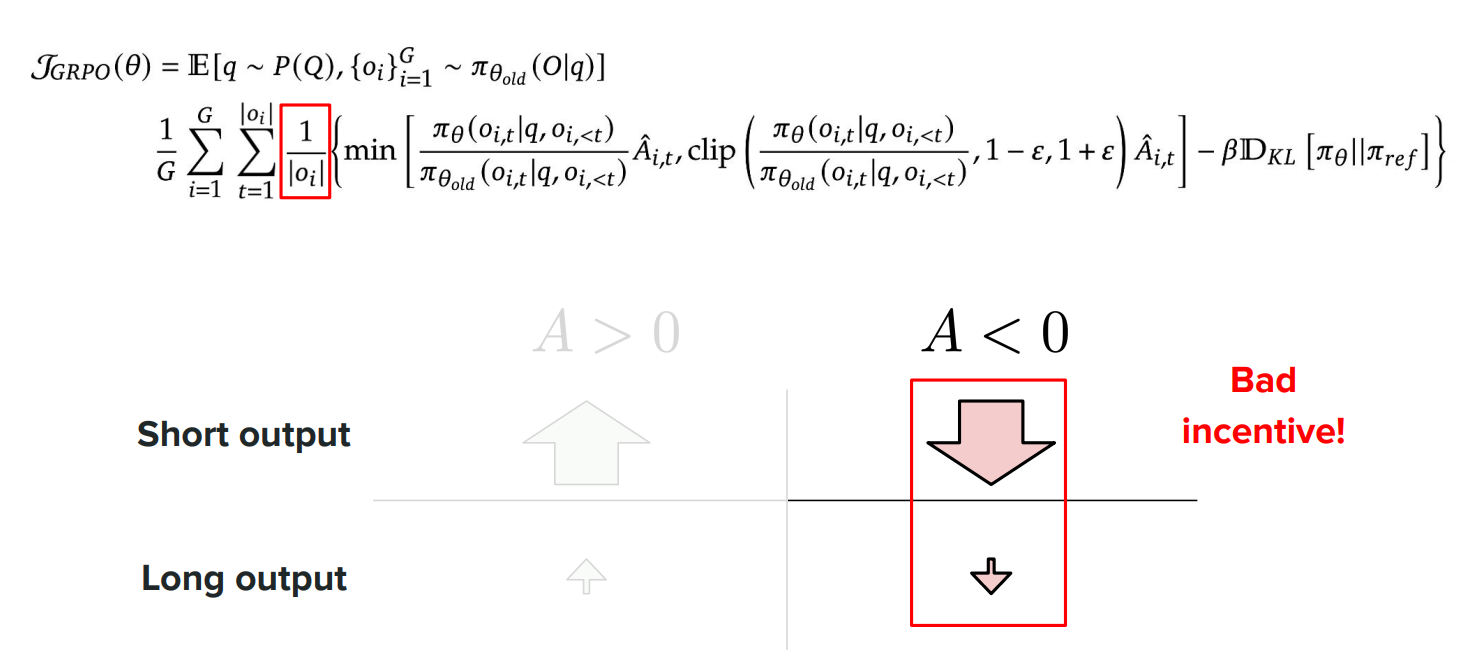

So the model learns:

- If I’m wrong, **be wrong verbosely**
- Longer bad outputs are **safer**

This explains why:
- Reasoning length keeps increasing
- Even after performance saturates

---

## Empirical Evidence

Plots show:
- Performance plateaus
- Output length continues increasing

This behavior aligns exactly with the incentive structure above.

---

## Fixes Introduced in 2025

### 1. DAPO (March 2025)

**Key idea:**  
Equalize token-level contributions.

Instead of:

$$
\frac{1}{|o_i|}
$$

Use:
- A **global normalization factor**
- Same weight for all tokens

Result:
- Tokens contribute equally
- No bias toward long outputs


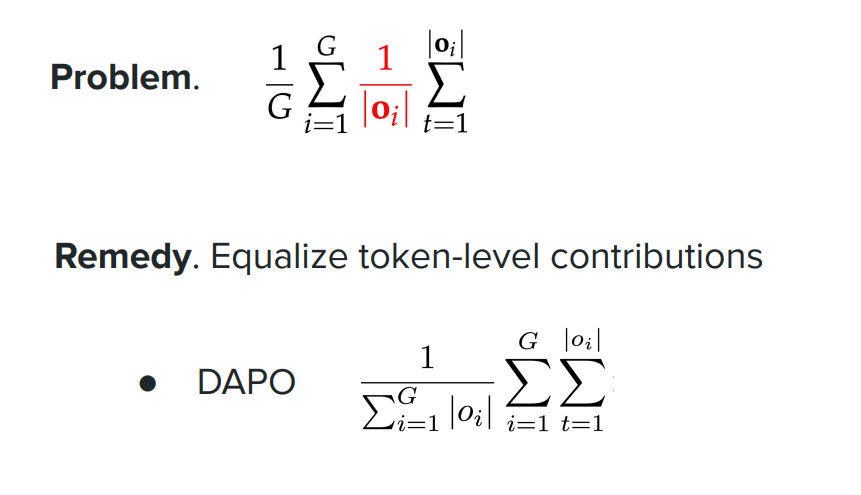

---

### 2. Dr. GRPO (GRPO Done Right)

**Key idea:**  
Remove the length normalization entirely.

That is:
- No $\frac{1}{|o_i|}$ term at all


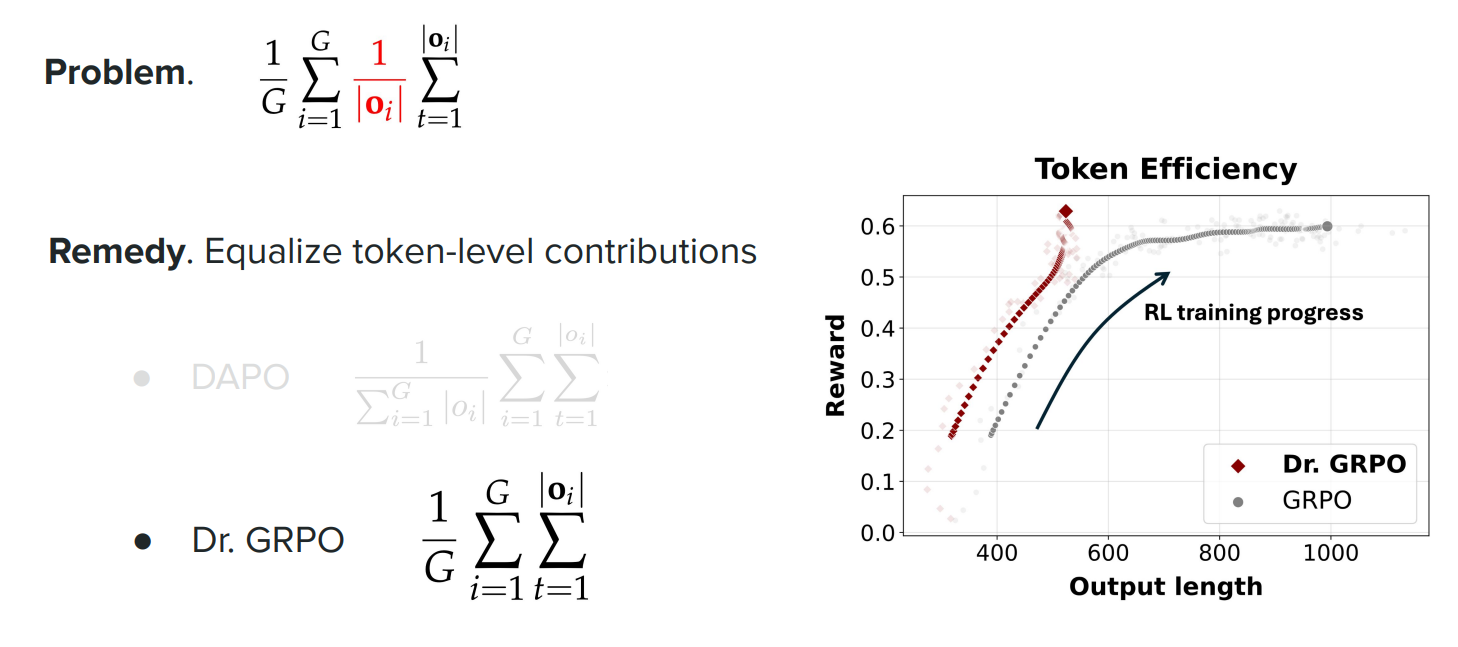
---

## Effects of These Fixes

Empirical results show:

- **Correct solutions**:
  - Similar lengths as GRPO
- **Incorrect solutions**:
  - Much shorter
  - No incentive to inflate reasoning

Overall:
- Output length stabilizes
- Performance remains strong


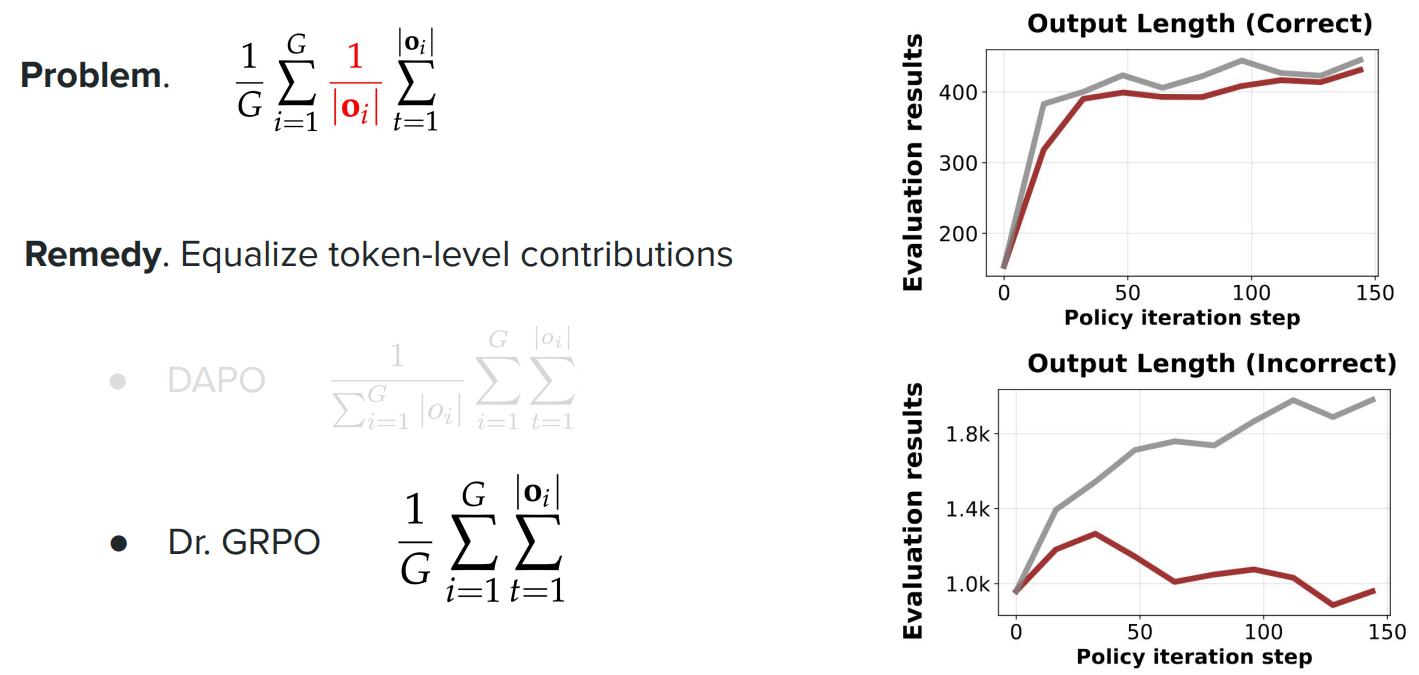


---

## Additional GRPO Modifications

### 1. Standard Deviation Issue in Advantage

Recall:

$$
A_i = \frac{r_i - \mu}{\sigma}
$$

Problem:
- For **very hard problems**
- Most completions fail
- $\sigma$ becomes very small

This can:
- Amplify noise
- Destabilize training

Various smoothing and clipping strategies are used to fix this.


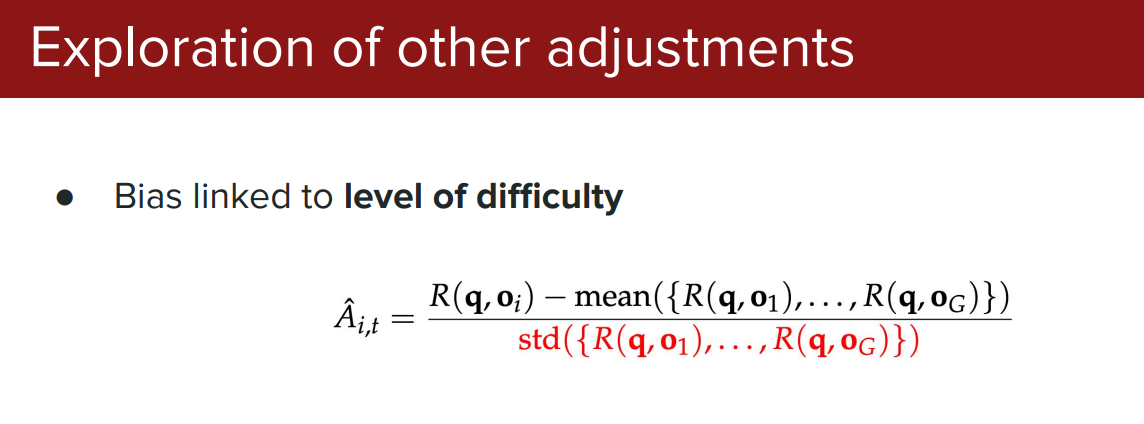
---

### 2. Asymmetric Clipping (Epsilon Adjustment)

Standard PPO-style clipping:

$$
r(\theta) \in [1-\epsilon, 1+\epsilon]
$$

Problem:
- If $\pi_{\text{old}}$ is very small:
  - Updates are severely limited
- If probabilities are large:
  - Risk of collapsing to zero

Solution:
- Use **asymmetric bounds**
- Different upper and lower epsilons

This allows:
- Low-probability tokens to grow
- High-probability tokens to remain stable



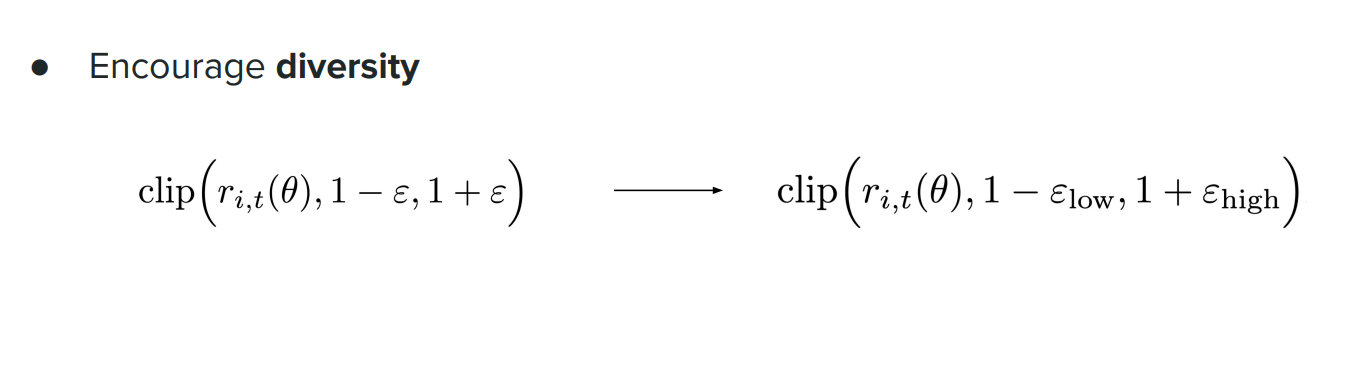
---

## Final Takeaways

- GRPO is powerful but **not perfect**
- Length explosion is a **mathematical artifact**, not a bug
- 2025 extensions:
  - Fix token-length bias
  - Improve efficiency
  - Preserve reasoning quality

These improvements are now **standard practice** in reasoning-model training.

---




# DeepSeek Reasoning Models: From R1-Zero to R1 (End-to-End Pipeline)

This section explains **how all previously discussed techniques (RL, GRPO, verifiable rewards, reasoning chains)** come together in practice, using the **DeepSeek R1 papers** as a concrete case study.

The goal is to understand:
- How **reasoning models are trained in reality**
- Why **R1-Zero** was a proof of concept
- How **R1** becomes a production-grade reasoning model
- How **distillation** enables smaller reasoning models

---

## Traditional LLM Training Pipeline (Recap)

Before reasoning models, the standard pipeline was:

1. **Pre-training**
   - Next-token prediction
   - Large-scale internet data
2. **Alignment**
   - Supervised Fine-Tuning (SFT / instruction tuning)
   - RL (preference-based, non-reasoning RL)

This produced **helpful assistants**, but **not strong reasoners**.

---

## DeepSeek’s Key Question

> *Can we get strong reasoning abilities **without** human-written chains of thought?*

DeepSeek answers this in **two stages**:
1. **R1-Zero** → proof that RL alone can induce reasoning
2. **R1** → full, stable, high-quality reasoning pipeline

---

## R1-Zero: RL-Only Proof of Concept

### Starting Point

- Model: **Pre-trained base model**
  - Next-token prediction only
  - No SFT
  - No instruction tuning
- Architecture:
  - Mixture of Experts (MoE)
  - Multi-Latent Attention (MLA)
  - Pre-Norm Transformer blocks

At this point, the model is a **plain base LLM**.


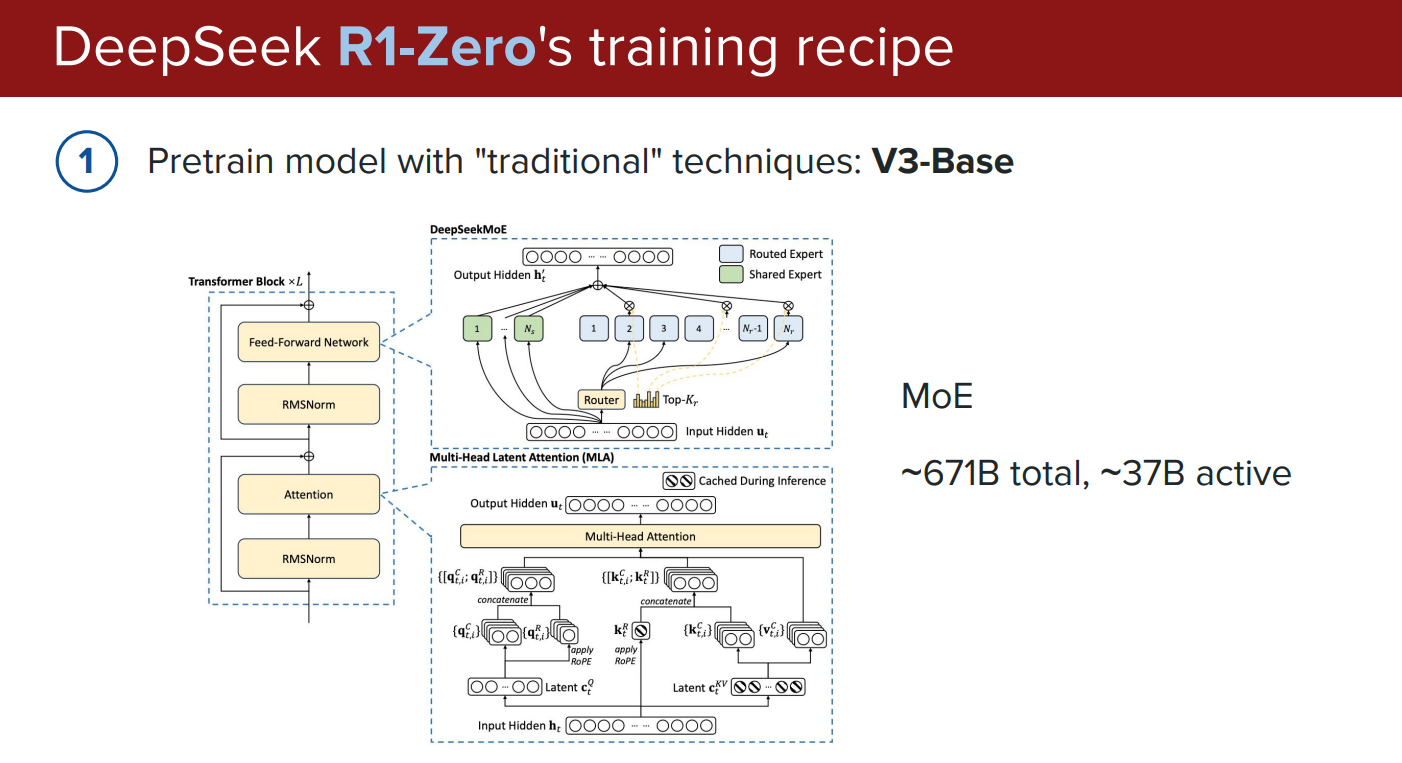
---

### Key Idea of R1-Zero

Instead of alignment via SFT:
- **Directly apply RL** on reasoning tasks
- Use **verifiable rewards only**

No human-written reasoning data.

---

### Prompt & Formatting Template

The model is instructed using a **fixed template**:

- System sets role: *helpful assistant*
- Model is told:
  - Put reasoning inside `<think> ... </think>`
  - Put final answer inside `<answer> ... </answer>`

Rewards are given for:
1. **Correct final answer** (verifiable)
2. **Correct formatting** (presence of think/answer blocks)

---

### RL Training Objective (R1-Zero)

The model is rewarded for:
- Producing a reasoning chain
- Producing a correct answer

No reward model needed:
- Math → check answer
- Code → run tests

---

### Empirical Result

On reasoning benchmarks (e.g. **AIME**):

- Accuracy **increases steadily** during RL
- This happens **without any SFT**

This proves:
> **Reasoning ability can emerge purely from RL with verifiable rewards**

---

### Problems Observed in R1-Zero

Despite strong benchmark performance, reasoning chains had issues:

1. **Language mixing**
   - Tokens from multiple languages
2. **Poor syntax**
3. **Low readability**
4. **Unstable formatting**

Reason:
- No supervised anchor
- RL optimizes reward, not clarity

---

## R1: Full Production-Grade Pipeline

R1 fixes R1-Zero’s weaknesses while keeping its strengths.

---

## Stage 0: Base Model (Same as R1-Zero)

- Start from **DeepSeek V3 base**
- Non-reasoning pretrained LLM

---

## Stage 1: Cold-Start SFT (Small but Critical)

### Motivation

- R1-Zero generated reasoning chains
- Some were **correct but messy**

### Solution

- Humans **rewrite a small subset** of R1-Zero CoTs
- Fix:
  - Language consistency
  - Formatting
  - Readability

### Result

- Small, high-quality dataset:
  - `(prompt, cleaned reasoning + answer)`

This anchors the model **before RL**.

---

## Stage 2: RL with Verifiable + Auxiliary Rewards

Now RL is applied again, but with **better constraints**.

### Rewards Used

1. **Correctness reward**
   - Math answer matches ground truth
   - Code passes tests

2. **Formatting reward**
   - Proper `<think>` and `<answer>` blocks

3. **Language consistency reward**
   - Simple heuristic:
     - Ratio of tokens in target language
   - Penalizes language mixing

This stabilizes reasoning chains **without human supervision at scale**.

---

## Stage 3: Large-Scale SFT (Reasoning + Non-Reasoning)

After RL, DeepSeek performs **another SFT stage**, but much larger.

### Data Composition

- **Non-reasoning data**
  - ~200k instruction-tuning pairs
  - Reused from DeepSeek V3
- **Reasoning data**
  - Ratio: **3 : 1 (reasoning : non-reasoning)**

---

### How Reasoning Data Is Generated

Using **rejection sampling**:

1. Sample reasoning responses from current model
2. Use heuristics / judges to evaluate quality
3. Keep only **high-quality reasoning traces**
4. Discard weak or incorrect ones

This yields **high-precision reasoning SFT data**.

---

## Stage 4: Final RL (Reasoning + Alignment)

Final RL stage combines:

### For Reasoning Prompts
- Verifiable correctness reward
- Formatting reward

### For Non-Reasoning Prompts
- **Helpfulness reward**
- **Harmlessness reward**

Important detail:
- Harmlessness is applied to **all tokens**
  - Including reasoning chains
- Prevents unsafe thoughts, not just unsafe answers

---

## Final Model: DeepSeek R1

### Observed Results

1. Clear separation:
   - Non-reasoning models → lower cluster
   - Reasoning models → higher cluster

2. **R1 matches or competes with closed-source reasoning models**
   - Despite being open
   - Despite transparent methodology

This was a major milestone in early 2025.


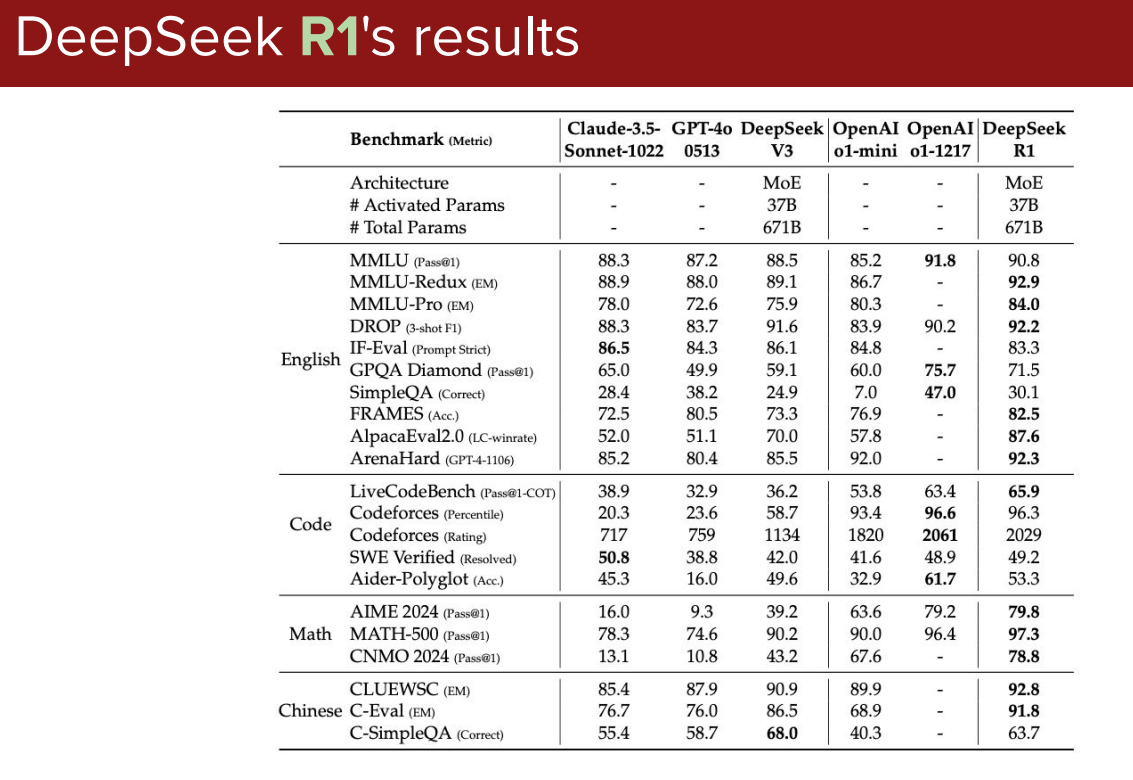
---

## Distillation: Reasoning for Smaller Models

### Problem

- Not everyone has:
  - 600B MoE
  - Massive RL compute

### Solution: Distillation


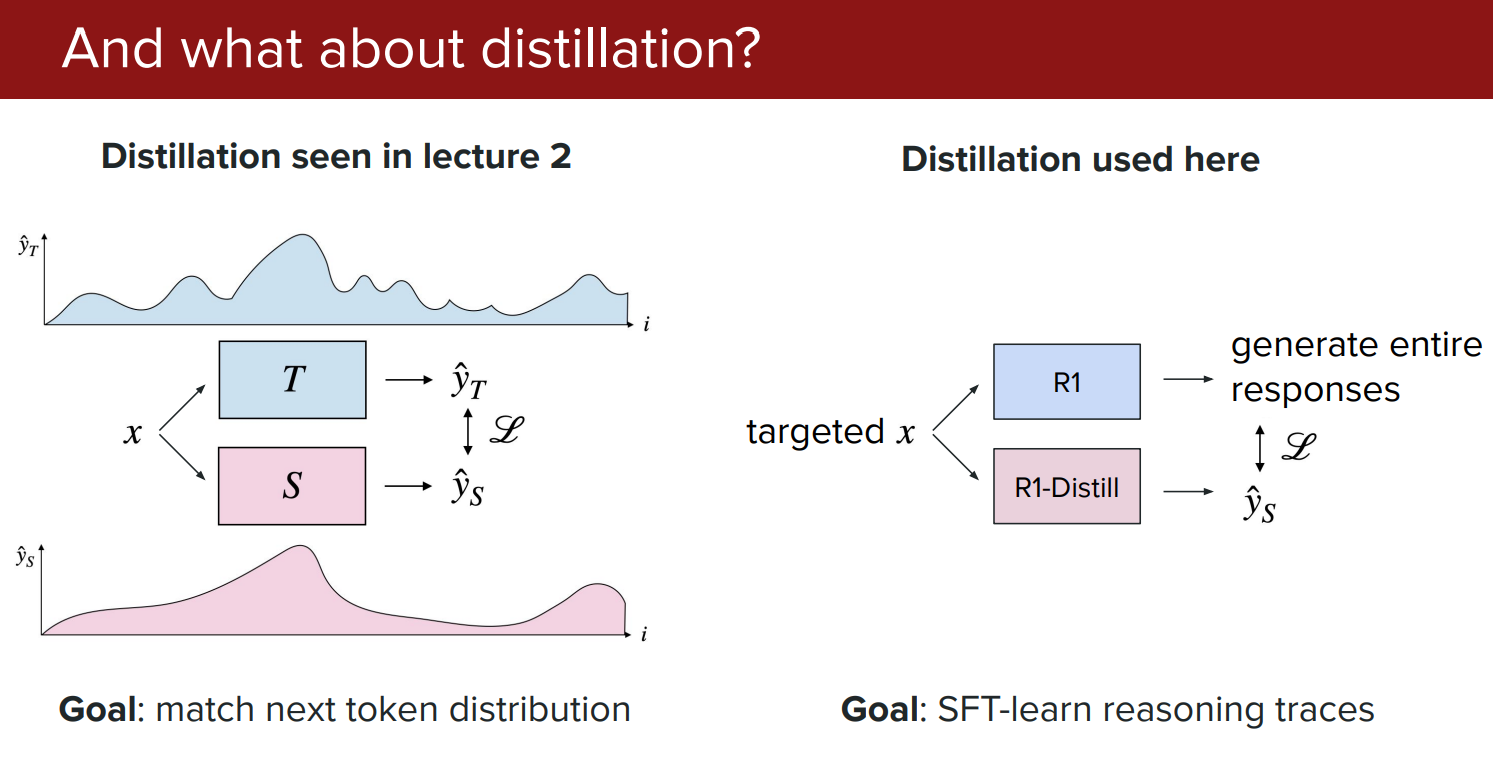
---

### Distillation Strategy for Reasoning Models

Different from classical distillation.

#### Teacher
- DeepSeek R1

#### Student
- Smaller model

#### Procedure

1. Teacher generates:
   - Full reasoning + answer sequences
2. Student is trained via **SFT**
   - Predict the **entire sequence**
   - No RL needed

This is **sequence-level distillation**, not token-probability distillation.

---

### Why This Works Better for Small Models

Empirical finding:
- Small models:
  - Struggle with RL from scratch
  - Benefit more from imitation

Thus:
> **Distillation > RL for small reasoning models**

---

## Final Results of Distillation

- Distilled models are:
  - Competitive with closed-source “mini” reasoning models (e.g. o1-mini)
  - Much cheaper to train and deploy


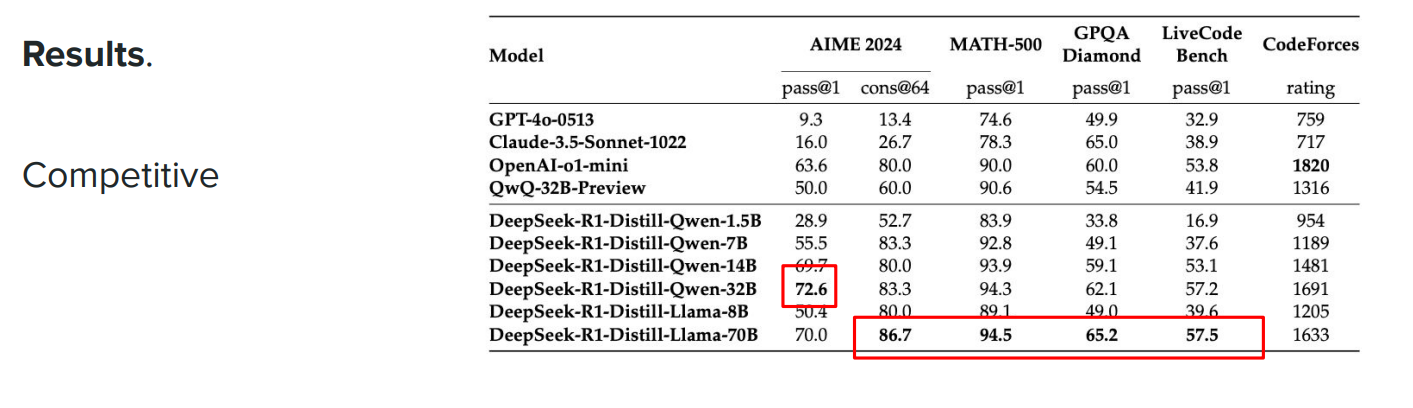
---

## Key Takeaways

- **R1-Zero** proves RL alone can induce reasoning
- **R1** adds structure, stability, and usability
- **Verifiable rewards** are the backbone of reasoning RL
- **GRPO** enables scalable reasoning training
- **Distillation** democratizes reasoning models

---

**End of DeepSeek Reasoning Pipeline**
